# TCX3901 — Delivery Performance: Report 1 Analysis 

**Problem:** Delivery performance (regression: lead time in days; classification: late vs on-time)
**Prediction point:** `order_purchase_timestamp` — the instant the order is placed
**Dataset:** Olist Brazilian E-Commerce Public Dataset

Name: Yeo Hui Hui 

This notebook reproduces every chart shown in Report 1

Sections:
1. Load raw tables
2. Build the order-level analytical table (joins, aggregation)
3. Data quality checks (the two traps from the handbook, plus the seller_state check)
4. Exploratory analysis (4 charts, revised)
5. Baseline — chronological train/test split, all baselines + full metrics


## 1. Load raw tables

All nine CSVs as supplied, with the five order timestamp columns parsed as dates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

PATH = "C:/Documents/02. NUS FILES Local/TCX3901 - Industrial Prac/dataset/"

orders = pd.read_csv(PATH + "olist_orders_dataset.csv", parse_dates=[
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date"
])
customers = pd.read_csv(PATH + "olist_customers_dataset.csv")
items = pd.read_csv(PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(PATH + "olist_sellers_dataset.csv")
translation = pd.read_csv(PATH + "product_category_name_translation.csv")
payments = pd.read_csv(PATH + "olist_order_payments_dataset.csv")

print("orders:", orders.shape)
print("customers:", customers.shape)
print("items:", items.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("payments:", payments.shape)

orders: (99441, 8)
customers: (99441, 5)
items: (112650, 7)
products: (32951, 9)
sellers: (3095, 4)
payments: (103886, 5)


## 2. Build the order-level analytical table

Only `delivered` orders with a real delivery date are kept. Items and payments are
aggregated up from line-item level to one row per order before joining.

In [2]:
print("Exact order_status values (needed to list the excluded statuses precisely):")
print(orders.order_status.value_counts())

Exact order_status values (needed to list the excluded statuses precisely):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [3]:
delivered = (
    orders[orders.order_status == "delivered"]
    .dropna(subset=["order_delivered_customer_date"])
    .copy()
)
print(f"{len(orders):,} orders -> {len(delivered):,} usable delivered orders")

delivered["lead_time_days"] = (
    delivered.order_delivered_customer_date - delivered.order_purchase_timestamp
).dt.total_seconds() / 86400

delivered["promised_days"] = (
    delivered.order_estimated_delivery_date - delivered.order_purchase_timestamp
).dt.total_seconds() / 86400

delivered["late"] = (
    delivered.order_delivered_customer_date > delivered.order_estimated_delivery_date
).astype(int)

delivered[["lead_time_days", "promised_days", "late"]].describe()

99,441 orders -> 96,470 usable delivered orders


,lead_time_days,promised_days,late
count,96470.000000,96470.000000,96470.000000
mean,12.558217,23.736343,0.081124
std,9.546156,8.761052,0.273026
min,0.533414,2.008009,0.000000
25%,6.766204,18.329905,0.000000
50%,10.217477,23.230880,0.000000
75%,15.720182,28.407795,0.000000
max,209.628611,155.135463,1.000000


In [4]:
# Customer join
delivered = delivered.merge(
    customers[["customer_id", "customer_unique_id", "customer_state", "customer_zip_code_prefix"]],
    on="customer_id", how="left"
)

# Items + products + sellers, aggregated to one row per order
items_products = (
    items
    .merge(products[["product_id", "product_category_name", "product_weight_g"]], on="product_id", how="left")
    .merge(translation, on="product_category_name", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
)

def mode_or_nan(s):
    m = s.mode()
    return m.iat[0] if len(m) > 0 else np.nan

order_agg = items_products.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    max_weight_g=("product_weight_g", "max"),
    n_sellers=("seller_id", "nunique"),
    main_category=("product_category_name_english", mode_or_nan),
    main_seller_state=("seller_state", mode_or_nan),
).reset_index()

full = delivered.merge(order_agg, on="order_id", how="left")

# Payments, aggregated to one row per order
pay_agg = payments.groupby("order_id").agg(
    n_installments=("payment_installments", "max"),
    total_payment=("payment_value", "sum"),
    payment_type=("payment_type", mode_or_nan),
).reset_index()

full = full.merge(pay_agg, on="order_id", how="left")

full["purchase_month"] = full.order_purchase_timestamp.dt.to_period("M").dt.to_timestamp()
full["purchase_dow"] = full.order_purchase_timestamp.dt.day_name()
full["is_cross_state"] = (full.customer_state != full.main_seller_state).astype(int)
# route = the seller-state x customer-state pair, used for the route-level baseline in Section 5
full["route"] = full.customer_state + "_" + full.main_seller_state.fillna("UNK")

print("Final order-level table:", full.shape)
full.head()

Final order-level table: (96470, 28)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,lead_time_days,promised_days,...,n_sellers,main_category,main_seller_state,n_installments,total_payment,payment_type,purchase_month,purchase_dow,is_cross_state,route
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063,...,1,housewares,SP,1.0,38.71,voucher,2017-10-01,Monday,0,SP_SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,19.137766,...,1,perfumery,SP,1.0,141.46,boleto,2018-07-01,Tuesday,1,BA_SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,26.639711,...,1,auto,SP,3.0,179.12,credit_card,2018-08-01,Wednesday,1,GO_SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,26.188819,...,1,pet_shop,MG,1.0,72.20,credit_card,2017-11-01,Saturday,1,RN_MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,12.112049,...,1,stationery,SP,1.0,28.62,credit_card,2018-02-01,Tuesday,0,SP_SP


## 3. Data quality checks

**Trap 1 — `customer_id` vs `customer_unique_id`.**
**Trap 2 — leakage** (delivery/carrier dates and review columns never used as features).
**Checked, not assumed — `seller_state` missingness.** The first draft of Report 1 cited a
`seller_state` gap in its risk section without ever quantifying it in the data model. It
turned out there isn't one — checked explicitly below.

In [5]:
print("Distinct customer_id:       ", customers.customer_id.nunique())
print("Distinct customer_unique_id:", customers.customer_unique_id.nunique())
print("-> repeat customers exist; always group by customer_unique_id for anything customer-level.\n")

print("Missing values in the joined table:")
print(full.isna().sum()[full.isna().sum() > 0])

print(f"\nMissing main_category: {full.main_category.isna().sum()} ({full.main_category.isna().mean():.1%})")
print(f"Missing main_seller_state: {full.main_seller_state.isna().sum()} ({full.main_seller_state.isna().mean():.2%})"
      " <- confirmed zero, so this is NOT a real risk")

Distinct customer_id:        99441
Distinct customer_unique_id: 96096
-> repeat customers exist; always group by customer_unique_id for anything customer-level.

Missing values in the joined table:
order_approved_at                 14
order_delivered_carrier_date       1
max_weight_g                      16
main_category                   1351
n_installments                     1
total_payment                      1
payment_type                       1
dtype: int64

Missing main_category: 1351 (1.4%)
Missing main_seller_state: 0 (0.00%) <- confirmed zero, so this is NOT a real risk


## 4. Exploratory analysis

The four figures, revised after feedback: Figure 1 now plots both distributions (not just one with an unlabelled line), Figure 3 has 95% confidence intervals, and Figure 4 labels sample sizes directly on the bars.

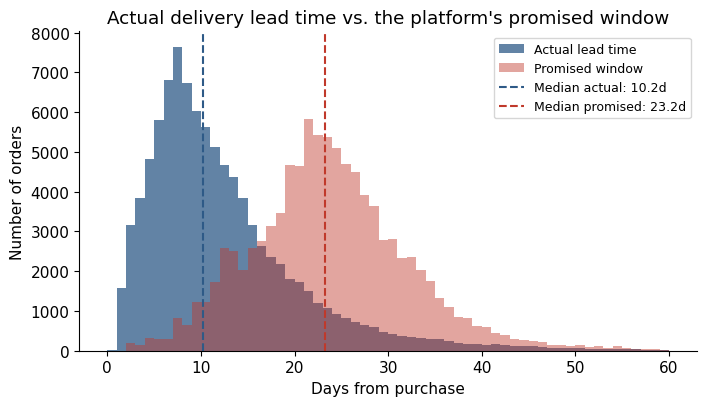

In [6]:
# Figure 1 (revised) — BOTH distributions plotted, with labelled medians
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.hist(full.lead_time_days, bins=60, range=(0, 60), color="#2E5A87", alpha=0.75, label="Actual lead time")
ax.hist(full.promised_days, bins=60, range=(0, 60), color="#C0392B", alpha=0.45, label="Promised window")
ax.axvline(full.lead_time_days.median(), color="#2E5A87", linestyle="--", linewidth=1.5,
           label=f"Median actual: {full.lead_time_days.median():.1f}d")
ax.axvline(full.promised_days.median(), color="#C0392B", linestyle="--", linewidth=1.5,
           label=f"Median promised: {full.promised_days.median():.1f}d")
ax.set_xlabel("Days from purchase")
ax.set_ylabel("Number of orders")
ax.set_title("Actual delivery lead time vs. the platform's promised window")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("chart1_leadtime_dist.png", dpi=150)
plt.show()

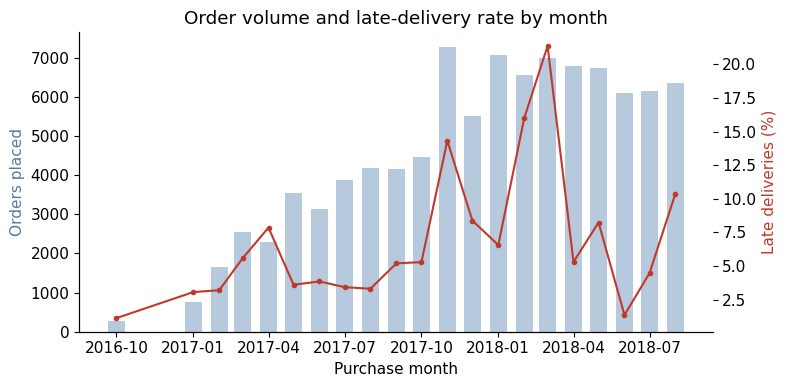

In [7]:
# Figure 2 — unchanged: monthly order volume and late-delivery rate
monthly = (
    full.groupby("purchase_month")
    .agg(orders=("order_id", "count"), late_rate=("late", "mean"))
    .reset_index()
)
monthly = monthly[monthly.orders >= 10]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(monthly.purchase_month, monthly.orders, width=20, color="#B7C9DC", label="Orders placed")
ax1.set_ylabel("Orders placed", color="#5A7A9C")
ax2 = ax1.twinx()
ax2.plot(monthly.purchase_month, monthly.late_rate * 100, color="#C0392B", marker="o", markersize=3, label="Late rate")
ax2.set_ylabel("Late deliveries (%)", color="#C0392B")
ax1.set_title("Order volume and late-delivery rate by month")
ax1.set_xlabel("Purchase month")
plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", dpi=150)
plt.show()

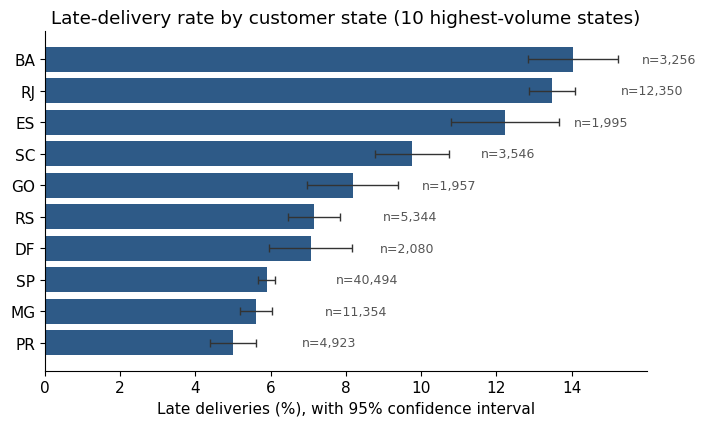

,customer_state,late_rate,n,se,ci
0,BA,0.140356,3256,0.006087,0.011931
1,RJ,0.134737,12350,0.003072,0.006022
2,ES,0.122306,1995,0.007335,0.014377
3,SC,0.097575,3546,0.004983,0.009767
4,GO,0.081758,1957,0.006194,0.012140
5,RS,0.071482,5344,0.003524,0.006907
6,DF,0.070673,2080,0.005619,0.011014
7,SP,0.058947,40494,0.001170,0.002294
8,MG,0.056104,11354,0.002160,0.004233
9,PR,0.049970,4923,0.003105,0.006086


In [8]:
# Figure 3 (revised) — with 95% confidence intervals, so "not a sample-size artefact"
# is backed by evidence rather than asserted
top_states = full.customer_state.value_counts().head(10).index
s = full[full.customer_state.isin(top_states)].groupby("customer_state").agg(
    late_rate=("late", "mean"), n=("order_id", "count")
)
s["se"] = np.sqrt(s.late_rate * (1 - s.late_rate) / s.n)
s["ci"] = 1.96 * s.se
s = s.sort_values("late_rate", ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(7.2, 4.4))
bars = ax.barh(s.customer_state, s.late_rate * 100, xerr=s.ci * 100, color="#2E5A87",
                error_kw=dict(ecolor="#333", capsize=3, elinewidth=1))
ax.invert_yaxis()
ax.set_xlabel("Late deliveries (%), with 95% confidence interval")
ax.set_title("Late-delivery rate by customer state (10 highest-volume states)")
for b, n in zip(bars, s.n):
    ax.text(b.get_width() + s.ci.max()*100 + 0.4, b.get_y() + b.get_height()/2, f"n={n:,}", va="center", fontsize=9, color="#555")
plt.tight_layout()
plt.savefig("chart3_state_late_rate.png", dpi=150)
plt.show()

s


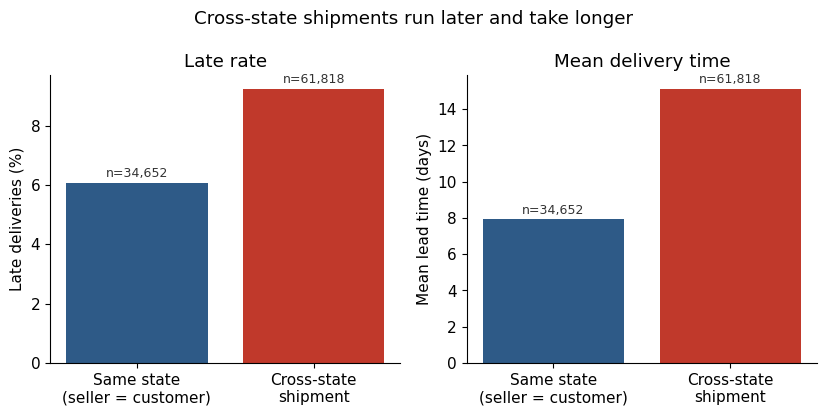

In [9]:
# Figure 4 (revised) — n labelled directly on the bars
grp = full.groupby("is_cross_state").agg(
    late_rate=("late", "mean"), mean_lead=("lead_time_days", "mean"), n=("order_id", "count")
).reset_index()
grp["label"] = grp.is_cross_state.map({0: "Same state\n(seller = customer)", 1: "Cross-state\nshipment"})

fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.2))
b0 = axes[0].bar(grp.label, grp.late_rate * 100, color=["#2E5A87", "#C0392B"])
axes[0].set_ylabel("Late deliveries (%)")
axes[0].set_title("Late rate")
for b, n in zip(b0, grp.n):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"n={n:,}", ha="center", fontsize=9, color="#333")
b1 = axes[1].bar(grp.label, grp.mean_lead, color=["#2E5A87", "#C0392B"])
axes[1].set_ylabel("Mean lead time (days)")
axes[1].set_title("Mean delivery time")
for b, n in zip(b1, grp.n):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"n={n:,}", ha="center", fontsize=9, color="#333")
fig.suptitle("Cross-state shipments run later and take longer")
plt.tight_layout()
plt.savefig("chart4_crossstate.png", dpi=150)
plt.show()


## 5. Baseline — chronological hold-out, all baselines + full metrics

Split chronologically because Section 4 shows late-rate spikes tied to specific months.
This revision adds: RMSE for every regression baseline (not just the platform one), a
route-level (seller-state x customer-state) baseline, and — on the classification side —
full precision/recall/F1/PR-AUC plus a second, non-trivial baseline.

In [10]:
full_sorted = full.sort_values("order_purchase_timestamp")
cutoff = full_sorted.order_purchase_timestamp.quantile(0.8)

train = full_sorted[full_sorted.order_purchase_timestamp <= cutoff]
test = full_sorted[full_sorted.order_purchase_timestamp > cutoff]

print(f"Cutoff date: {cutoff}")
print(f"Train: {len(train):,} orders | Test: {len(test):,} orders")


Cutoff date: 2018-05-26 18:17:10.200000
Train: 77,176 orders | Test: 19,294 orders


In [11]:
# --- Regression baselines: MAE and RMSE for all four ---
def mae_rmse(actual, pred):
    err = actual - pred
    return err.abs().mean(), np.sqrt((err ** 2).mean())

global_mean = train.lead_time_days.mean()
mae_g, rmse_g = mae_rmse(test.lead_time_days, global_mean)

state_means = train.groupby("customer_state").lead_time_days.mean()
pred_state = test.customer_state.map(state_means).fillna(global_mean)
mae_s, rmse_s = mae_rmse(test.lead_time_days, pred_state)

cross_means = train.groupby("is_cross_state").lead_time_days.mean()
pred_cross = test.is_cross_state.map(cross_means)
mae_c, rmse_c = mae_rmse(test.lead_time_days, pred_cross)

route_means = train.groupby("route").lead_time_days.mean()
pred_route = test.route.map(route_means).fillna(global_mean)
mae_r, rmse_r = mae_rmse(test.lead_time_days, pred_route)
n_routes = train.route.nunique()
n_unseen = (~test.route.isin(route_means.index)).sum()

mae_p, rmse_p = mae_rmse(test.lead_time_days, test.promised_days)

print("REGRESSION BASELINES (test set, days)")
print(f"  Platform's promised date as the prediction : MAE={mae_p:.2f}  RMSE={rmse_p:.2f}")
print(f"  Global historical mean                      : MAE={mae_g:.2f}  RMSE={rmse_g:.2f}")
print(f"  Same/cross-state 2-bucket mean               : MAE={mae_c:.2f}  RMSE={rmse_c:.2f}")
print(f"  Customer-state mean                          : MAE={mae_s:.2f}  RMSE={rmse_s:.2f}")
print(f"  Seller-state x customer-state route mean     : MAE={mae_r:.2f}  RMSE={rmse_r:.2f}   <- chosen baseline")
print(f"    ({n_routes} distinct routes in train; {n_unseen} test orders fell back to global mean, route unseen in train)")

print(f"\nReconciling headline numbers:")
print(f"  Mean PROMISED days, full data:      {full.promised_days.mean():.2f}")
print(f"  Mean ACTUAL lead time, train only:  {train.lead_time_days.mean():.2f}")
print(f"  MAE of promised-vs-actual, test:    {mae_p:.2f}  (this is MAE, not a simple mean difference)")


REGRESSION BASELINES (test set, days)
  Platform's promised date as the prediction : MAE=13.14  RMSE=15.92
  Global historical mean                      : MAE=6.43  RMSE=7.58
  Same/cross-state 2-bucket mean               : MAE=5.86  RMSE=7.10
  Customer-state mean                          : MAE=5.74  RMSE=6.98
  Seller-state x customer-state route mean     : MAE=5.63  RMSE=6.94   <- chosen baseline
    (392 distinct routes in train; 28 test orders fell back to global mean, route unseen in train)

Reconciling headline numbers:
  Mean PROMISED days, full data:      23.74
  Mean ACTUAL lead time, train only:  13.51
  MAE of promised-vs-actual, test:    13.14  (this is MAE, not a simple mean difference)


In [12]:
# --- Classification: full metrics for the majority-class rule AND a non-trivial baseline ---
majority_class = train.late.mode()[0]
preds_majority = np.full(len(test), majority_class)

acc1 = (test.late == majority_class).mean()
prec1 = precision_score(test.late, preds_majority, zero_division=0)
rec1 = recall_score(test.late, preds_majority, zero_division=0)
f1_1 = f1_score(test.late, preds_majority, zero_division=0)
pr_auc1 = test.late.mean()  # a constant classifier has no ranking; PR-AUC collapses to prevalence

# Non-trivial baseline: flag every cross-state shipment as "late", motivated by Figure 4
preds_crossstate = test.is_cross_state.values
acc2 = (test.late == preds_crossstate).mean()
prec2 = precision_score(test.late, preds_crossstate, zero_division=0)
rec2 = recall_score(test.late, preds_crossstate, zero_division=0)
f1_2 = f1_score(test.late, preds_crossstate, zero_division=0)
pr_auc2 = average_precision_score(test.late, preds_crossstate)

print("CLASSIFICATION BASELINES (test set)")
print(f"  Train late rate: {train.late.mean():.1%} | Test late rate: {test.late.mean():.1%}\n")
print(f"  Always predict '{'late' if majority_class else 'on-time'}':")
print(f"    Accuracy={acc1:.4f}  Precision={prec1:.4f}  Recall={rec1:.4f}  F1={f1_1:.4f}  PR-AUC(trivial)={pr_auc1:.4f}")
print(f"\n  Flag every cross-state shipment as 'late' (non-trivial baseline):")
print(f"    Accuracy={acc2:.4f}  Precision={prec2:.4f}  Recall={rec2:.4f}  F1={f1_2:.4f}  PR-AUC={pr_auc2:.4f}")
print("\n  -> The majority-class rule's 94.7% accuracy hides 0.00 recall. The cross-state rule")
print("     catches over a third of late deliveries (recall 0.35) at low precision (0.03) --")
print("     a concrete illustration of the precision/recall trade-off. Report 2 must beat")
print("     recall=0.35 / F1=0.057, not the misleadingly high accuracy figures above.")


CLASSIFICATION BASELINES (test set)
  Train late rate: 8.8% | Test late rate: 5.3%

  Always predict 'on-time':
    Accuracy=0.9471  Precision=0.0000  Recall=0.0000  F1=0.0000  PR-AUC(trivial)=0.0529

  Flag every cross-state shipment as 'late' (non-trivial baseline):
    Accuracy=0.3876  Precision=0.0313  Recall=0.3526  F1=0.0574  PR-AUC=0.0453

  -> The majority-class rule's 94.7% accuracy hides 0.00 recall. The cross-state rule
     catches over a third of late deliveries (recall 0.35) at low precision (0.03) --
     a concrete illustration of the precision/recall trade-off. Report 2 must beat
     recall=0.35 / F1=0.057, not the misleadingly high accuracy figures above.


## Next steps (Semester 2)

- Compare category and `seller_state` missingness rates between late and on-time orders
  (moved up to recess week per the revised work plan — `seller_state` is confirmed clean,
  but category missingness at 1.4% still needs this check)
- Add a seller-customer distance feature from `olist_geolocation_dataset.csv`
- Fit pipelines (preprocessing inside cross-validation folds) for 2-3 model families per framing
- Compare against 5.63 days MAE (route baseline) and recall=0.35/F1=0.057 (cross-state
  classification baseline); keep the customer-state-only baseline (5.74 days) as a fallback
  if the route baseline proves unstable on new data
